In [1]:
from datascience import *
import matplotlib.pyplot as plots
%matplotlib inline
plots.style.use('fivethirtyeight')

In [2]:
actor = Table.read_table('../../Data/actors.csv')
actor

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Harrison Ford,4871.7,41,118.8,Star Wars: The Force Awakens,936.7
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Tom Hanks,4340.8,44,98.7,Toy Story 3,415
"Robert Downey, Jr.",3947.3,53,74.5,The Avengers,623.4
Eddie Murphy,3810.4,38,100.3,Shrek 2,441.2
Tom Cruise,3587.2,36,99.6,War of the Worlds,234.3
Johnny Depp,3368.6,45,74.9,Dead Man's Chest,423.3
Michael Caine,3351.5,58,57.8,The Dark Knight,534.9
Scarlett Johansson,3341.2,37,90.3,The Avengers,623.4


## 1.Scatter

Text(0.5, 1.0, 'Bieu do 1')

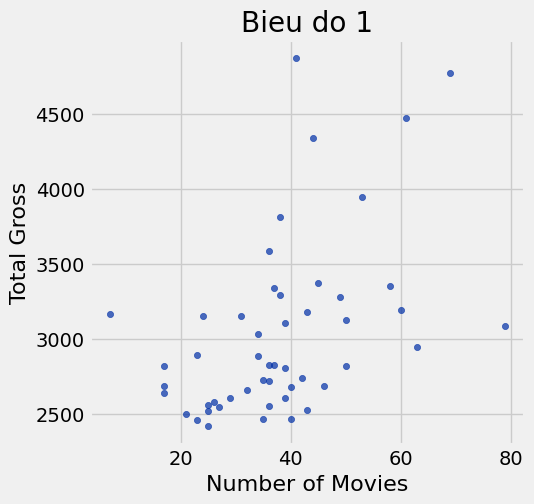

In [3]:
actor.scatter('Number of Movies','Total Gross')
plots.title('Bieu do 1')

## 2.Plot line

In [4]:
movies = Table.read_table('../../Data/movies_by_year.csv')
movies

Year,Total Gross,Number of Movies,#1 Movie
2015,11128.5,702,Star Wars: The Force Awakens
2014,10360.8,702,American Sniper
2013,10923.6,688,Catching Fire
2012,10837.4,667,The Avengers
2011,10174.3,602,Harry Potter / Deathly Hallows (P2)
2010,10565.6,536,Toy Story 3
2009,10595.5,521,Avatar
2008,9630.7,608,The Dark Knight
2007,9663.8,631,Spider-Man 3
2006,9209.5,608,Dead Man's Chest


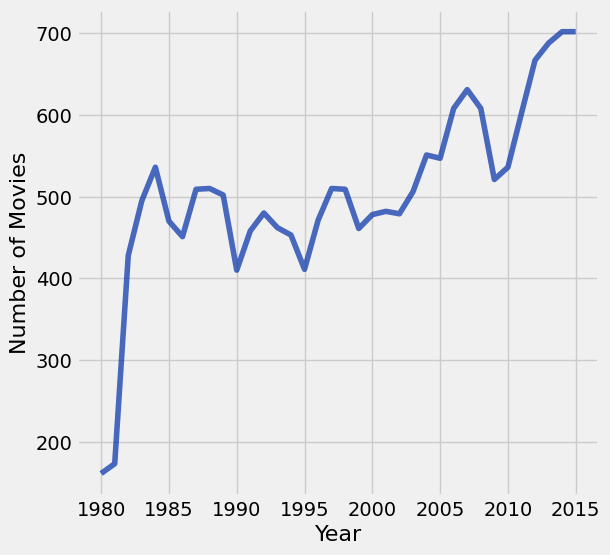

In [5]:
movies.plot('Year','Number of Movies')

## 3.Visualizing Categorical Distributions

In [6]:
icecream = Table().with_columns(
    'Flavor', make_array('Chocolate', 'Strawberry', 'Vanilla'),
    'Number of Cartons', make_array(16, 5, 9)
)
icecream

Flavor,Number of Cartons
Chocolate,16
Strawberry,5
Vanilla,9


3.1 Bar chart

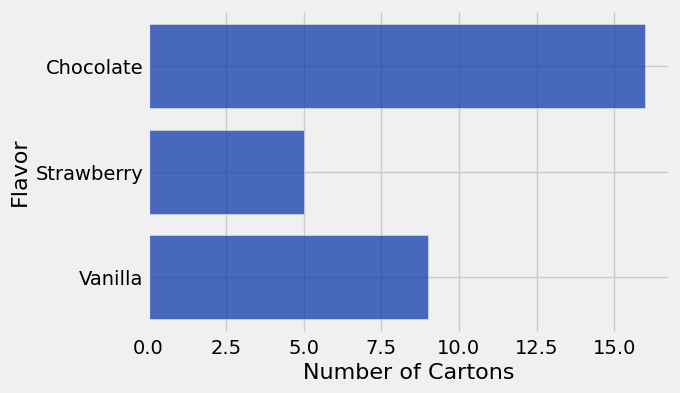

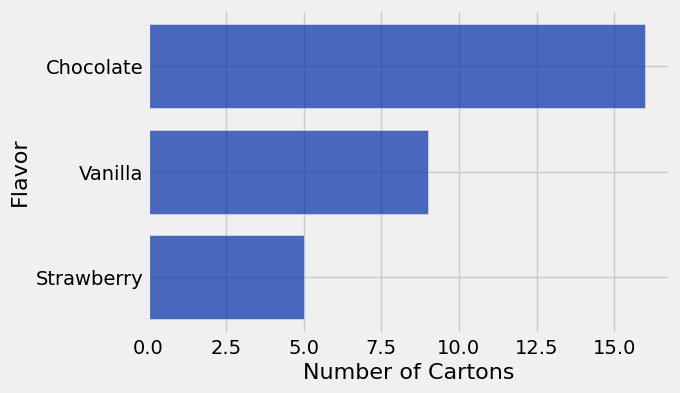

In [7]:
icecream.barh('Flavor', 'Number of Cartons')
icecream.sort('Number of Cartons', descending = True ).barh('Flavor','Number of Cartons')

## 4.Visualizing Numerical Distributions

4.1 Binning the data

In [8]:
movies_top = Table.read_table('../../Data/top_movies_2017.csv')
movies_top

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


In [9]:
import numpy as np
adjust_reception = movies_top.select(0).with_column(
    'adjusted_gross', movies_top.column('Gross (Adjusted)')/1e6
)

bin1 = adjust_reception.bin('adjusted_gross', bins = np.arange(300,1800,100)).show()
bin2 =  adjust_reception.bin('adjusted_gross').show()



bin,adjusted_gross count
300,68
400,60
500,32
600,15
700,7
800,7
900,3
1000,0
1100,3
1200,3


bin,adjusted_gross count
338.409,115
484.186,50
629.963,14
775.739,10
921.516,3
1067.29,4
1213.07,2
1358.85,0
1504.62,1
1650.4,1


4.2 Histogram

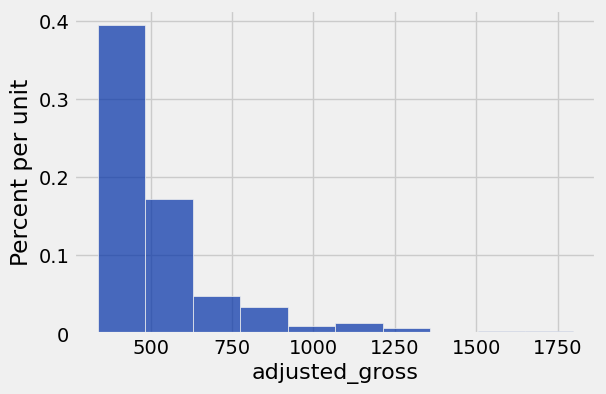

In [11]:
adjust_reception.hist('adjusted_gross')


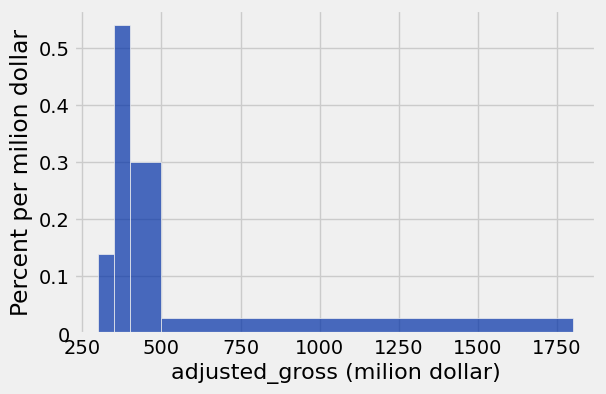

In [ ]:
ls = make_array(300, 350, 400, 500, 1800)
gr_gross = adjust_reception.hist('adjusted_gross', bins = ls,unit = 'milion dollar')


## Tinh toan chieu cao cac cot tren bieu do tren

In [ ]:
tb_gross = adjust_reception.bin('adjusted_gross', bins = ls)
tb_gross

bin,adjusted_gross count
300,14
350,54
400,60
500,72
1800,0


In [45]:
total = np.sum(tb_gross.column('adjusted_gross count'))
tb_gross = tb_gross.with_column('percent' , np.round(tb_gross.column('adjusted_gross count')*100/total,2))
number_row = tb_gross.num_rows - 1
width = np.diff(tb_gross.column('bin'))
tb_gross = tb_gross.take(np.arange(number_row))
tb_gross =tb_gross.with_column(
    'width' ,  width
)
tb_gross


bin,adjusted_gross count,percent,width
300,14,7,50
350,54,27,50
400,60,30,100
500,72,36,1300


In [48]:
tb_gross = tb_gross.with_column('high', np.round(tb_gross.column('percent')/tb_gross.column('width'),2))
tb_gross

bin,adjusted_gross count,percent,width,high
300,14,7,50,0.14
350,54,27,50,0.54
400,60,30,100,0.3
500,72,36,1300,0.03


## 5.Overlaid Graphs

In [50]:
# Read the full Census table
data = '../../Data/nc-est2019-agesex-res.csv'
full_census_table = Table.read_table(data)

# Select columns from the full table and relabel some of them
partial_census_table = full_census_table.select('SEX', 'AGE', 'POPESTIMATE2014', 'POPESTIMATE2019')
us_pop = partial_census_table.relabeled('POPESTIMATE2014', '2014').relabeled('POPESTIMATE2019', '2019')

# Access the rows corresponding to all children, ages 0-18
children = us_pop.where('SEX', are.equal_to(0)).where('AGE', are.below(19)).drop('SEX')
children.show()

AGE,2014,2019
0,3954787,3783052
1,3948891,3829599
2,3958711,3922044
3,4005928,3998665
4,4004032,4043323
5,4004576,4028281
6,4133372,4017227
7,4152666,4022319
8,4118349,4066194
9,4106068,4061874


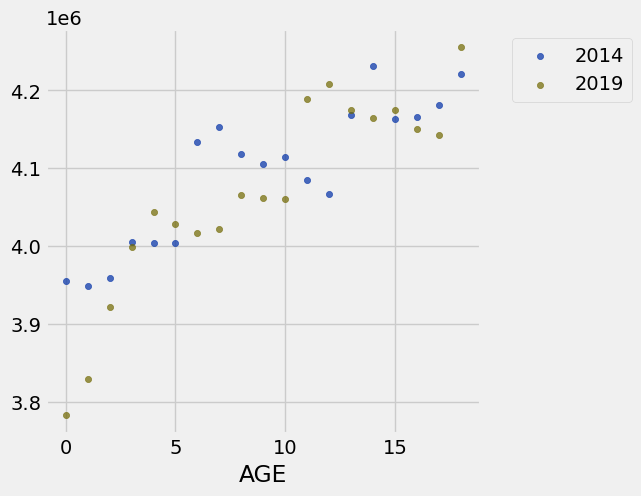

In [59]:
children = children.with_column('hj',0)
children.scatter('AGE',['2014','2019'])


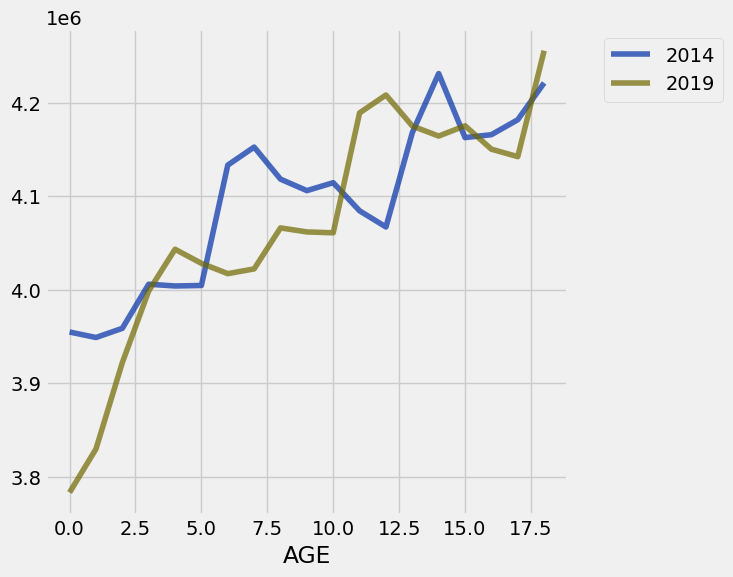

In [61]:
children.plot('AGE',['2014','2019'])

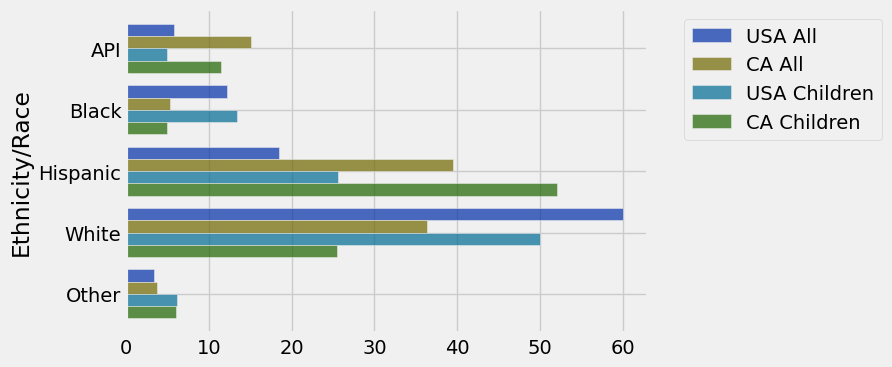

In [63]:
usa = Table.read_table('../../Data/usa_ca_2019.csv')
usa.barh('Ethnicity/Race')